# Real RAG Evaluation Dashboard

**A live control panel for the RAG system — real queries, real evaluation, real drift detection.**

This notebook runs 30 queries through the production RAG pipeline, evaluates retrieval and
generation quality using both deterministic and LLM-as-judge metrics, detects statistical drift
against a baseline, and tests the ReAct agent. All results are posted to Phoenix for interactive
exploration.

| Component | Details |
|-----------|---------|
| **LLM** | `qwen3-30b-instruct` via llama.cpp at `http://127.0.0.1:8002/v1` |
| **Phoenix** | `http://localhost:6006` — traces + eval annotations |
| **Embeddings** | `all-MiniLM-L6-v2` (sentence-transformers, local) |
| **Index** | FAISS, 30 Wikipedia articles, pre-built |
| **QA Pairs** | 30 questions across 3 clusters (AI/ML, History, Science) |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from pathlib import Path
from collections import Counter

import requests
from openai import OpenAI
from phoenix.otel import register

from rag import (
    RAGPipeline, RAGAgent, RAGResult,
    DocumentIndexer, QADataset, QAPair,
    DriftDetector, DriftReport, Generator,
    Retriever, RetrievalResult,
    PHOENIX_URL, LLM_BASE_URL, MODEL_NAME, PROJECT_NAME, INDEX_DIR,
)
from rag.evaluators.code_evals import (
    hit_rate_at_k, mrr, precision_at_k,
    contains_expected, exact_match, answer_length_ok, context_precision,
)
from rag.evaluators.llm_evals import hallucination_eval, relevance_eval, correctness_eval
from rag.evaluators.poster import post_eval_scores, post_code_eval_scores
from rag.evaluators.agent_evals import tool_accuracy, step_efficiency, final_answer_correct
from phoenix.evals import evaluate_dataframe

# Style
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})
CLUSTER_COLORS = {"ai_ml": "#3498db", "history": "#e74c3c", "science": "#2ecc71"}

# Register OTel tracing with Phoenix
tracer_provider = register(
    project_name=PROJECT_NAME,
    endpoint=f"{PHOENIX_URL}/v1/traces",
)

# ── Health checks ──
health = []
try:
    r = requests.get(f"{PHOENIX_URL}/healthz", timeout=5)
    health.append({"Component": "Phoenix", "Status": "\u2713 OK", "Details": PHOENIX_URL})
except Exception:
    health.append({"Component": "Phoenix", "Status": "\u2717 DOWN", "Details": "Not reachable"})

try:
    _oai = OpenAI(base_url=LLM_BASE_URL, api_key="not-needed")
    _models = _oai.models.list()
    health.append({"Component": "LLM", "Status": "\u2713 OK",
                   "Details": f"{_models.data[0].id} at {LLM_BASE_URL}"})
except Exception as e:
    health.append({"Component": "LLM", "Status": "\u2717 DOWN", "Details": str(e)[:80]})

indexer = DocumentIndexer()
indexer.load()
health.append({"Component": "FAISS Index", "Status": "\u2713 OK",
               "Details": f"{len(indexer.chunks):,} chunks, {indexer.index.ntotal:,} vectors"})

dataset = QADataset()
qa_pairs = dataset.load()
health.append({"Component": "QA Pairs", "Status": "\u2713 OK",
               "Details": f"{len(qa_pairs)} pairs, clusters: {sorted(set(p.cluster for p in qa_pairs))}"})

pd.DataFrame(health)

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: rag-pipeline
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



,Component,Status,Details
0,Phoenix,✓ OK,http://localhost:6006
1,LLM,✓ OK,qwen3-30b-instruct at http://127.0.0.1:8002/v1
2,FAISS Index,✓ OK,"5,496 chunks, 5,496 vectors"
3,QA Pairs,✓ OK,"30 pairs, clusters: ['ai_ml', 'history', 'scie..."


In [2]:
# ── QA pairs overview ──
qa_df = pd.DataFrame([
    {"#": i+1, "Question": p.question[:70], "Cluster": p.cluster,
     "Source Article": p.source_article, "Doc ID": (p.relevant_doc_ids or ["?"])[0]}
    for i, p in enumerate(qa_pairs)
])
print(f"QA Dataset: {len(qa_pairs)} questions across {qa_df['Cluster'].nunique()} clusters\n")
qa_df

QA Dataset: 30 questions across 3 clusters



,#,Question,Cluster,Source Article,Doc ID
0,1,What is Large language model and how does it w...,ai_ml,Large language model,doc_14
1,2,Explain the key concepts behind Transformer (d...,ai_ml,Transformer (deep learning),doc_25
2,3,Explain the key concepts behind Retrieval-augm...,ai_ml,Retrieval-augmented generation,doc_22
3,4,What is Prompt engineering and how does it work?,ai_ml,Prompt engineering,doc_19
4,5,Explain the key concepts behind Vector database.,ai_ml,Vector database,doc_27
5,6,What is the significance of Word embedding in ...,ai_ml,Word embedding,doc_28
6,7,What is the significance of BERT (language mod...,ai_ml,BERT (language model),doc_1
7,8,What is GPT-4 and how does it work?,ai_ml,GPT-4,doc_11
8,9,What is Fine-tuning (deep learning) and how do...,ai_ml,Fine-tuning (deep learning),doc_9
9,10,Explain the key concepts behind Hallucination ...,ai_ml,Hallucination (artificial intelligence),doc_12


---
## Section 1 — Run the Pipeline (Real Queries)

Every query flows through the full RAG pipeline: **embed query → FAISS search → build context →
LLM generate**. Each query produces an OpenTelemetry trace with nested spans, automatically sent
to Phoenix. The `trace_id` links each result to its trace in the Phoenix UI.

This cell runs all 30 QA pairs and saves results to `pipeline_results.csv` so later sections can
reload without re-running the pipeline.

In [3]:
pipeline = RAGPipeline(indexer=indexer)

results = []
t0 = time.time()
for i, qa in enumerate(qa_pairs):
    print(f"\r  [{i+1:2d}/{len(qa_pairs)}] {qa.question[:55]}...", end="", flush=True)
    result = pipeline.query(
        question=qa.question,
        ground_truth=qa.ground_truth_answer,
        relevant_doc_ids=qa.relevant_doc_ids,
        cluster=qa.cluster,
    )
    top_score = result.retrieved_chunks[0].score if result.retrieved_chunks else 0
    results.append({
        "question": result.question,
        "generated_answer": result.answer,
        "expected_answer": qa.ground_truth_answer,
        "context": result.context,
        "trace_id": result.trace_id,
        "latency_ms": round(result.latency_ms, 1),
        "retrieved_doc_ids": json.dumps(result.retrieved_doc_ids),
        "relevant_doc_ids": json.dumps(qa.relevant_doc_ids or []),
        "top_retrieval_score": round(top_score, 4),
        "cluster": qa.cluster,
        "source_article": qa.source_article,
    })

elapsed = time.time() - t0
df = pd.DataFrame(results)
df.to_csv("pipeline_results.csv", index=False)
print(f"\n\n\u2713 {len(df)} queries complete in {elapsed:.0f}s")
print(f"  Mean latency: {df['latency_ms'].mean():.0f}ms | Median: {df['latency_ms'].median():.0f}ms")
print(f"  Saved to pipeline_results.csv")

  [ 1/30] What is Large language model and how does it work?...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [30/30] Explain the fundamental principles of Neuroscience....i...

✓ 30 queries complete in 82s
  Mean latency: 2742ms | Median: 1882ms
  Saved to pipeline_results.csv


In [4]:
# ── Display results (load from CSV if needed) ──
try:
    df
except NameError:
    df = pd.read_csv("pipeline_results.csv")

display_df = df[["question", "generated_answer", "latency_ms", "cluster", "trace_id"]].copy()
display_df["question"] = display_df["question"].str[:60]
display_df["generated_answer"] = display_df["generated_answer"].str[:80]
display_df["phoenix"] = display_df["trace_id"].apply(lambda t: f"{PHOENIX_URL}/traces/{t}")
display_df.drop(columns=["trace_id"], inplace=True)
display_df

,question,generated_answer,latency_ms,cluster,phoenix
0,What is Large language model and how does it w...,A large language model (LLM) is a computationa...,26958.6,ai_ml,http://localhost:6006/traces/2c0ddce4ab1d13fa7...
1,Explain the key concepts behind Transformer (d...,onnections and layer normalization. \n- **Enc...,4196.8,ai_ml,http://localhost:6006/traces/a0ffca149d5492ef3...
2,Explain the key concepts behind Retrieval-augm...,tion not present in their training data. \n2....,3095.1,ai_ml,http://localhost:6006/traces/6e668f7c6ebd095a8...
3,What is Prompt engineering and how does it work?,engineering is the process of structuring natu...,1608.3,ai_ml,http://localhost:6006/traces/969b74bc37e573cb2...
4,Explain the key concepts behind Vector database.,Vector databases store and retrieve data embed...,1271.9,ai_ml,http://localhost:6006/traces/9d36f83db46a957a5...
5,What is the significance of Word embedding in ...,Word embeddings are significant in artificial ...,1165.7,ai_ml,http://localhost:6006/traces/f030974bc1fe32ec5...
6,What is the significance of BERT (language mod...,BERT is significant in artificial intelligence...,1159.5,ai_ml,http://localhost:6006/traces/e82b083941691b085...
7,What is GPT-4 and how does it work?,"PT series, capable of generating human-like te...",2054.6,ai_ml,http://localhost:6006/traces/b5e67e4267fb5d840...
8,What is Fine-tuning (deep learning) and how do...,rning is a transfer learning technique where a...,1769.8,ai_ml,http://localhost:6006/traces/fb3020a4eedced697...
9,Explain the key concepts behind Hallucination ...,that contains false or misleading information ...,1932.5,ai_ml,http://localhost:6006/traces/1b29c8f3b5522a21d...


---
## Section 2 — Retrieval Quality

Before we can judge the LLM's answer, we need to know: **did the retriever find the right
documents?** If the wrong chunks go in, even a perfect LLM will produce a wrong answer.

These are **code evaluators** — deterministic, instant, free:
- **Hit Rate @5**: Did the correct document appear anywhere in the top 5 results?
- **MRR** (Mean Reciprocal Rank): *Where* did it appear? (1st = 1.0, 2nd = 0.5, not found = 0.0)
- **Precision @5**: What fraction of the top 5 results were actually relevant?

In [5]:
# ── Compute retrieval metrics ──
try:
    df
except NameError:
    df = pd.read_csv("pipeline_results.csv")

df["_ret_ids"] = df["retrieved_doc_ids"].apply(json.loads)
df["_rel_ids"] = df["relevant_doc_ids"].apply(json.loads)

df["hit_rate"] = df.apply(lambda r: hit_rate_at_k(r["_ret_ids"], r["_rel_ids"]), axis=1)
df["mrr"] = df.apply(lambda r: mrr(r["_ret_ids"], r["_rel_ids"]), axis=1)
df["precision_at_k"] = df.apply(lambda r: precision_at_k(r["_ret_ids"], r["_rel_ids"]), axis=1)
df["contains_expected"] = df.apply(lambda r: contains_expected(r["generated_answer"], r["expected_answer"]), axis=1)
df["answer_length_ok"] = df.apply(lambda r: answer_length_ok(r["generated_answer"]), axis=1)
# context_precision: what fraction of retrieved chunks contributed to the answer?
df["context_precision"] = df.apply(
    lambda r: context_precision(
        r["generated_answer"],
        r.get("context", "").split("\n---\n") if isinstance(r.get("context"), str) else []
    ), axis=1
)

# Post to Phoenix
trace_ids = df["trace_id"].tolist()
for metric in ["hit_rate", "mrr", "precision_at_k"]:
    try:
        post_code_eval_scores(trace_ids, metric, df[metric].tolist())
    except Exception as e:
        print(f"  Warning: could not post {metric}: {e}")

print("Retrieval Metrics Summary")
print("=" * 50)
for metric in ["hit_rate", "mrr", "precision_at_k", "context_precision"]:
    print(f"  {metric:20s}  mean={df[metric].mean():.3f}  min={df[metric].min():.3f}")
print(f"\n  Queries with hit_rate=0: {(df['hit_rate'] == 0).sum()}/{len(df)}")
print(f"  Mean context_precision: {df['context_precision'].mean():.3f}  (fraction of retrieved chunks actually used)")

Retrieval Metrics Summary
  hit_rate              mean=1.000  min=1.000
  mrr                   mean=0.961  min=0.333
  precision_at_k        mean=0.806  min=0.333
  context_precision     mean=0.787  min=0.400

  Queries with hit_rate=0: 0/30
  Mean context_precision: 0.787  (fraction of retrieved chunks actually used)


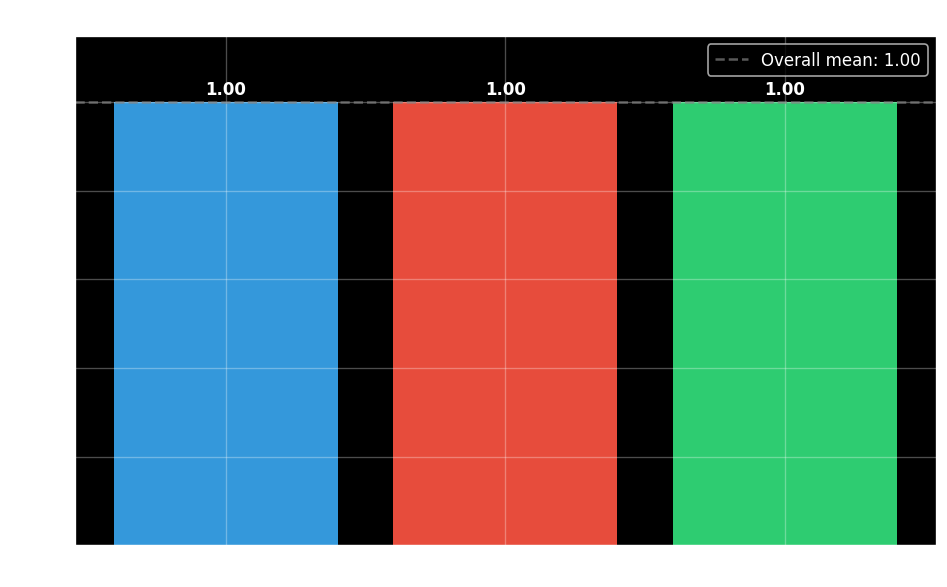

In [6]:
# ── Bar chart: hit rate per topic cluster ──
fig, ax = plt.subplots(figsize=(8, 5))
cluster_hit = df.groupby("cluster")["hit_rate"].mean().sort_values()
bars = ax.bar(cluster_hit.index, cluster_hit.values,
              color=[CLUSTER_COLORS.get(c, "#999") for c in cluster_hit.index])
ax.axhline(y=cluster_hit.mean(), color="gray", linestyle="--", alpha=0.7,
           label=f"Overall mean: {cluster_hit.mean():.2f}")
ax.set_ylabel("Hit Rate @5")
ax.set_title("Retrieval Hit Rate by Topic Cluster")
ax.set_ylim(0, 1.15)
for bar, val in zip(bars, cluster_hit.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

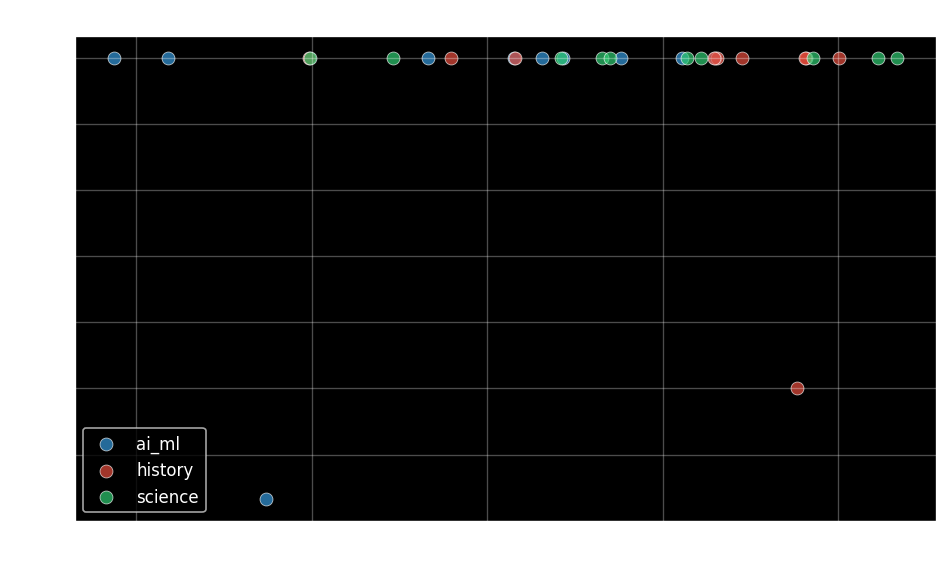

In [7]:
# ── Scatter: MRR vs FAISS distance ──
fig, ax = plt.subplots(figsize=(8, 5))
for cluster, color in CLUSTER_COLORS.items():
    mask = df["cluster"] == cluster
    ax.scatter(df.loc[mask, "top_retrieval_score"], df.loc[mask, "mrr"],
               c=color, label=cluster, alpha=0.7, s=60, edgecolors="white", linewidth=0.5)
ax.set_xlabel("Top FAISS L2 Distance (lower = more similar)")
ax.set_ylabel("MRR")
ax.set_title("Does Closer Embedding Distance Mean Better Ranking?")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# ── Retrieval failures ──
failures = df[df["hit_rate"] == 0][["question", "source_article", "_ret_ids", "_rel_ids"]].copy()
if len(failures) == 0:
    print("\u2713 No retrieval failures — every query found a relevant document in top 5.")
else:
    failures = failures.rename(columns={"_ret_ids": "Retrieved", "_rel_ids": "Expected"})
    failures["question"] = failures["question"].str[:60]
    print(f"\u26a0 {len(failures)} retrieval failures (hit_rate@5 = 0):\n")
    display(failures)

✓ No retrieval failures — every query found a relevant document in top 5.


---
## Section 3 — Answer Quality (LLM-as-Judge)

Code evaluators tell us *if* the right documents were retrieved. Now we ask: **was the answer
actually good?** This requires LLM-as-judge evaluation — we ask the same Qwen model to score
each answer on three dimensions:

| Metric | Type | Question it answers |
|--------|------|-------------------|
| **Hallucination** | Categorical | Does the answer only use facts from the context? |
| **Relevance** | Categorical | Does the answer address the question? |
| **Correctness** | Continuous | How close is it to the ground truth? |

Each evaluator makes a separate LLM call (~7-30s each). With 30 queries and 3 evaluators,
expect ~5-15 minutes total. Scores are posted to Phoenix as trace annotations.

> **These match the annotation configs already registered in Phoenix** — hallucination
> (CATEGORICAL: FAITHFUL/HALLUCINATED), relevance (CATEGORICAL: HIGH/MEDIUM/LOW),
> correctness (CONTINUOUS: 0.0-1.0).

In [9]:
# ── Run LLM-as-judge evaluators ──
try:
    df
except NameError:
    df = pd.read_csv("pipeline_results.csv")
    df["_ret_ids"] = df["retrieved_doc_ids"].apply(json.loads)
    df["_rel_ids"] = df["relevant_doc_ids"].apply(json.loads)

eval_df = df[["question", "generated_answer", "expected_answer", "context"]].copy()

evaluators_to_run = [
    ("hallucination", hallucination_eval),
    ("relevance", relevance_eval),
    ("correctness", correctness_eval),
]

for eval_name, evaluator in evaluators_to_run:
    print(f"Running {eval_name} eval on {len(eval_df)} queries...")
    t0 = time.time()
    result = evaluate_dataframe(dataframe=eval_df, evaluators=[evaluator])
    elapsed = time.time() - t0
    col = f"{eval_name}_score"
    if col in result.columns:
        df[col] = result[col].values
    print(f"  \u2713 {eval_name} complete in {elapsed:.1f}s")

# Extract numeric scores and labels
def _extract(val, key="score"):
    if isinstance(val, dict):
        return val.get(key)
    return val

df["hallucination_label"] = df["hallucination_score"].apply(lambda v: _extract(v, "label") or "UNKNOWN")
df["hallucination_numeric"] = df["hallucination_score"].apply(lambda v: _extract(v, "score") if isinstance(v, dict) else 0.5)
df["relevance_label"] = df["relevance_score"].apply(lambda v: _extract(v, "label") or "UNKNOWN")
df["relevance_numeric"] = df["relevance_score"].apply(lambda v: _extract(v, "score") if isinstance(v, dict) else 0.5)
df["correctness_numeric"] = df["correctness_score"].apply(lambda v: _extract(v, "score") if isinstance(v, dict) else 0.0)

# Post scores to Phoenix
trace_ids = df["trace_id"].tolist()
for eval_name in ["hallucination", "relevance", "correctness"]:
    try:
        col = f"{eval_name}_score"
        temp_df = pd.DataFrame({col: df[col].values})
        post_eval_scores(temp_df, eval_name, trace_ids)
        print(f"  Posted {eval_name} annotations to Phoenix")
    except Exception as e:
        print(f"  Warning: could not post {eval_name}: {e}")

# Save full eval results
df.to_csv("eval_results.csv", index=False)
print(f"\n\u2713 All evaluations complete. Saved to eval_results.csv")
print(f"  Faithfulness: {(df['hallucination_label'] == 'FAITHFUL').mean():.0%}")
print(f"  Relevance (HIGH): {(df['relevance_label'] == 'HIGH').mean():.0%}")
print(f"  Correctness mean: {df['correctness_numeric'].mean():.2f}")

Running hallucination eval on 30 queries...


Evaluating Dataframe |          | 0/30 (0.0%) | ⏳ 00:00<? | ?it/s

  ✓ hallucination complete in 11.8s
Running relevance eval on 30 queries...


Evaluating Dataframe |          | 0/30 (0.0%) | ⏳ 00:00<? | ?it/s

  ✓ relevance complete in 9.7s
Running correctness eval on 30 queries...


Evaluating Dataframe |          | 0/30 (0.0%) | ⏳ 00:00<? | ?it/s

  ✓ correctness complete in 11.9s
  Posted hallucination annotations to Phoenix
  Posted relevance annotations to Phoenix
  Posted correctness annotations to Phoenix

✓ All evaluations complete. Saved to eval_results.csv
  Faithfulness: 97%
  Relevance (HIGH): 97%
  Correctness mean: 0.88


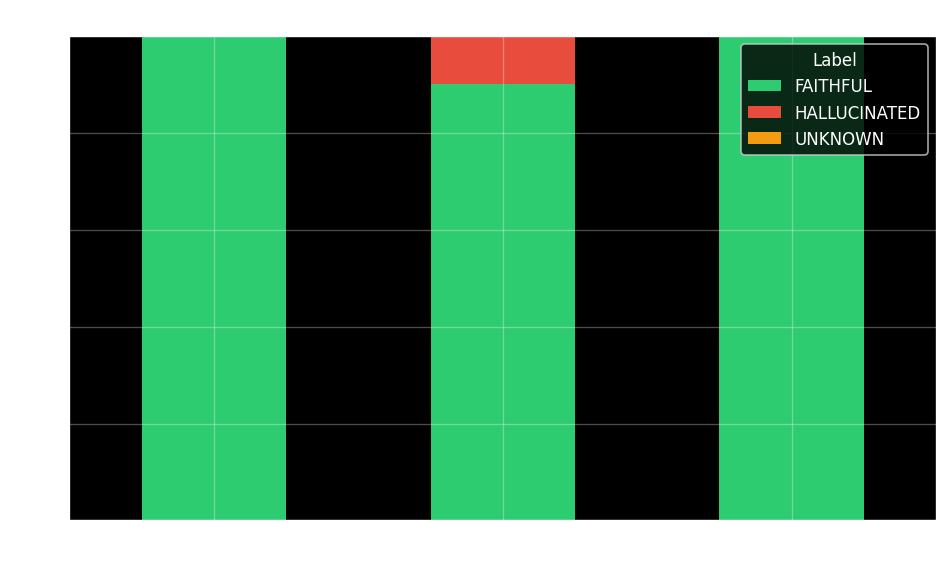

In [10]:
# ── Stacked bar: hallucination breakdown per cluster ──
fig, ax = plt.subplots(figsize=(8, 5))
label_order = ["FAITHFUL", "HALLUCINATED", "UNKNOWN"]
hall_colors = {"FAITHFUL": "#2ecc71", "HALLUCINATED": "#e74c3c", "UNKNOWN": "#f39c12"}

hall_counts = df.groupby(["cluster", "hallucination_label"]).size().unstack(fill_value=0)
for label in label_order:
    if label not in hall_counts.columns:
        hall_counts[label] = 0
hall_counts = hall_counts[label_order]
hall_counts.plot(kind="bar", stacked=True, ax=ax,
                 color=[hall_colors[c] for c in label_order])
ax.set_ylabel("Count")
ax.set_title("Hallucination Breakdown by Cluster")
ax.legend(title="Label")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

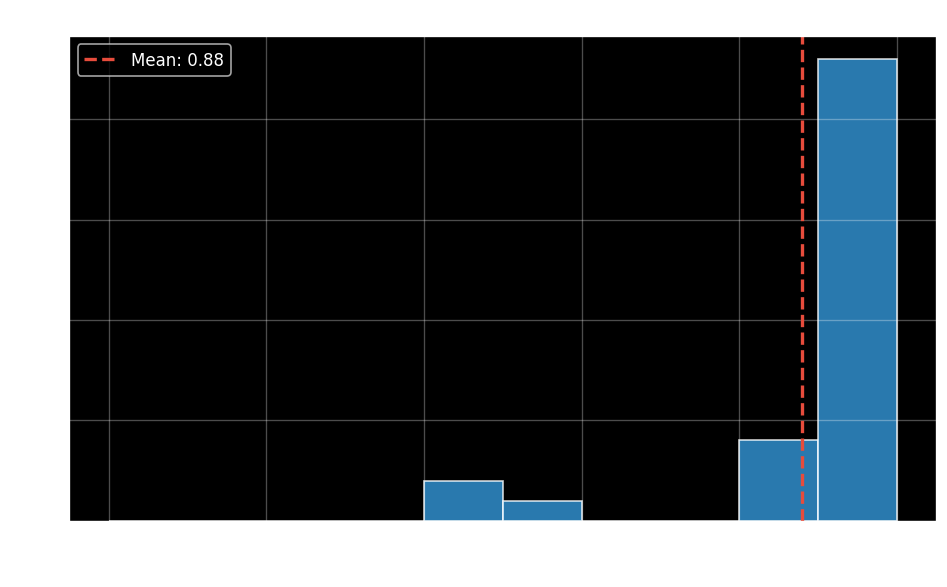

In [11]:
# ── Histogram: correctness score distribution ──
fig, ax = plt.subplots(figsize=(8, 5))
vals = df["correctness_numeric"].dropna()
ax.hist(vals, bins=10, range=(0, 1), color="#3498db", edgecolor="white", alpha=0.8)
mean_val = vals.mean()
ax.axvline(mean_val, color="#e74c3c", linestyle="--", linewidth=2,
           label=f"Mean: {mean_val:.2f}")
ax.set_xlabel("Correctness Score")
ax.set_ylabel("Count")
ax.set_title("Answer Correctness Distribution (0.0 = wrong, 1.0 = perfect)")
ax.legend()
plt.tight_layout()
plt.show()

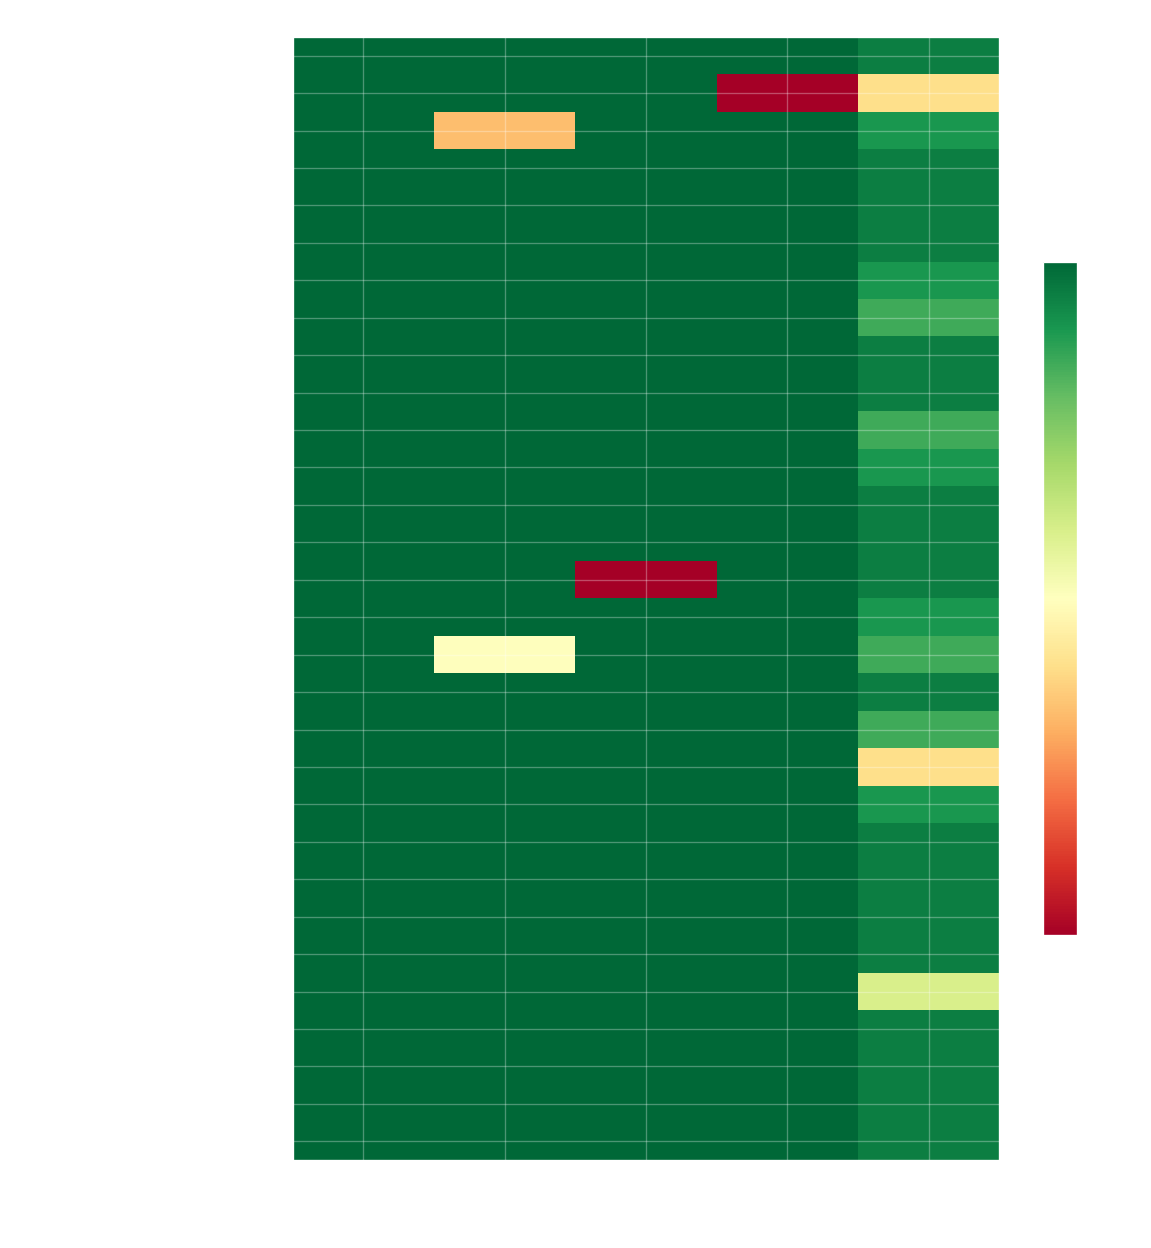

In [12]:
# ── Heatmap: question x metric ──
metric_cols = ["hit_rate", "mrr", "hallucination_numeric", "relevance_numeric", "correctness_numeric"]
for col in metric_cols:
    if col not in df.columns:
        df[col] = 0.0

heatmap_data = df[metric_cols].fillna(0).values
labels = [q[:40] + "..." if len(q) > 40 else q for q in df["question"]]
col_labels = ["Hit Rate", "MRR", "Faithful", "Relevant", "Correct"]

fig, ax = plt.subplots(figsize=(10, max(8, len(labels) * 0.35)))
im = ax.imshow(heatmap_data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_title("Per-Query Evaluation Heatmap (green = good, red = bad)")
plt.colorbar(im, ax=ax, label="Score", shrink=0.6)
plt.tight_layout()
plt.show()

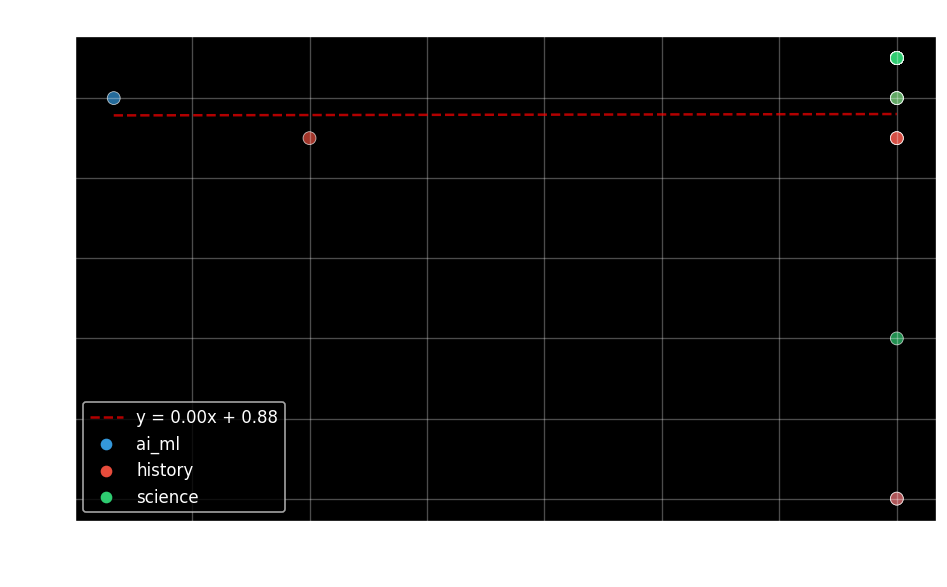

In [13]:
# ── Correlation: MRR vs correctness ──
fig, ax = plt.subplots(figsize=(8, 5))
x = df["mrr"].values
y = df["correctness_numeric"].fillna(0).values
colors = [CLUSTER_COLORS.get(c, "#999") for c in df["cluster"]]
ax.scatter(x, y, c=colors, alpha=0.7, s=60, edgecolors="white", linewidth=0.5)

# Regression line
valid = ~np.isnan(x) & ~np.isnan(y)
if valid.sum() > 2:
    z = np.polyfit(x[valid], y[valid], 1)
    p = np.poly1d(z)
    x_line = np.linspace(x[valid].min(), x[valid].max(), 50)
    ax.plot(x_line, p(x_line), "r--", alpha=0.7, label=f"y = {z[0]:.2f}x + {z[1]:.2f}")
    from scipy.stats import pearsonr
    r_val, p_val = pearsonr(x[valid], y[valid])
    ax.set_title(f"Retrieval Quality vs Answer Quality (r={r_val:.2f}, p={p_val:.3f})")
else:
    ax.set_title("Retrieval Quality vs Answer Quality")

ax.set_xlabel("MRR (Retrieval Ranking)")
ax.set_ylabel("Correctness (Answer Quality)")
# Cluster legend
for cluster, color in CLUSTER_COLORS.items():
    ax.scatter([], [], c=color, label=cluster)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# ── Worst 5 queries by overall score ──
score_cols = ["hit_rate", "mrr", "hallucination_numeric", "relevance_numeric", "correctness_numeric"]
df["overall_score"] = df[score_cols].fillna(0).mean(axis=1)
worst = df.nsmallest(5, "overall_score")[
    ["question", "generated_answer", "expected_answer", "cluster", "overall_score"]
    + score_cols
].copy()
worst["question"] = worst["question"].str[:50]
worst["generated_answer"] = worst["generated_answer"].str[:60]
worst["expected_answer"] = worst["expected_answer"].str[:60]
for col in score_cols + ["overall_score"]:
    worst[col] = worst[col].round(2)

print("Bottom 5 Queries by Overall Score")
print("=" * 80)
worst

Bottom 5 Queries by Overall Score


,question,generated_answer,expected_answer,cluster,overall_score,hit_rate,mrr,hallucination_numeric,relevance_numeric,correctness_numeric
1,Explain the key concepts behind Transformer (d...,onnections and layer normalization. \n- **Enc...,"In deep learning, the transformer is a family ...",ai_ml,0.68,1.0,1.00,1.0,0.0,0.40
14,Describe the key events and significance of Mo...,"hing from the Sea of Japan to Eastern Europe, ...",The Mongol Empire was the largest contiguous e...,history,0.79,1.0,1.00,0.0,1.0,0.95
2,Explain the key concepts behind Retrieval-augm...,tion not present in their training data. \n2....,Retrieval-augmented generation (RAG) is a tech...,ai_ml,0.85,1.0,0.33,1.0,1.0,0.90
16,What role did Cold War play in shaping the mod...,The Cold War shaped the modern world by establ...,The Cold War was a period of international geo...,history,0.87,1.0,0.50,1.0,1.0,0.85
19,What was British Empire and what were its main...,"velopment of property rights, which fueled the...","The British Empire comprised the dominions, co...",history,0.88,1.0,1.00,1.0,1.0,0.40


---
## Section 4 — Baseline & Drift Detection

A good score *today* doesn't mean the pipeline is healthy *tomorrow*. Drift detection compares
the current evaluation run against a saved baseline.

**How it works:**
1. First run → save metric means/stds as `baseline.json`
2. Subsequent runs → load baseline, compute z-scores per metric
3. If |z| > 2.0 → flag as **drifted** (current performance is 2+ standard deviations from baseline)

For latency, *higher* is worse. For all other metrics, *lower* is worse.

Each run is also appended to `run_history.jsonl` so we can plot metric trends over time.

In [15]:
# ── Baseline & drift ──
try:
    df
except NameError:
    df = pd.read_csv("eval_results.csv")

BASELINE_PATH = Path("baseline.json")
HISTORY_PATH = Path("run_history.jsonl")

# Build drift DataFrame
drift_metrics = {
    "hit_rate": df["hit_rate"].mean() if "hit_rate" in df.columns else 0,
    "mrr": df["mrr"].mean() if "mrr" in df.columns else 0,
    "hallucination_score": df["hallucination_numeric"].mean() if "hallucination_numeric" in df.columns else 0,
    "relevance_score": df["relevance_numeric"].mean() if "relevance_numeric" in df.columns else 0,
    "correctness_score": df["correctness_numeric"].mean() if "correctness_numeric" in df.columns else 0,
    "latency_ms": df["latency_ms"].mean() if "latency_ms" in df.columns else 0,
    "context_precision": df["context_precision"].mean() if "context_precision" in df.columns else 0,
}

drift_df = pd.DataFrame([drift_metrics] * len(df))  # replicate for DriftDetector
for col in drift_metrics:
    if col.replace("_score", "_numeric") in df.columns and col != "latency_ms" and col not in ["hit_rate", "mrr"]:
        drift_df[col] = df[col.replace("_score", "_numeric")].values
    elif col in df.columns:
        drift_df[col] = df[col].values

detector = DriftDetector(baseline_path=str(BASELINE_PATH))

if not BASELINE_PATH.exists():
    detector.fit(drift_df)
    print("\u2713 First run — baseline saved to baseline.json")
    print("  (Run the notebook again to see drift comparison)")
    drift_report = None
else:
    drift_report = detector.check(drift_df)
    print(drift_report.summary())

# Append to run history
run_record = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    **{k: round(v, 4) for k, v in drift_metrics.items()},
}
with open(HISTORY_PATH, "a") as f:
    f.write(json.dumps(run_record) + "\n")
print(f"\nRun appended to {HISTORY_PATH}")

Drift Report
  hit_rate                   baseline=1.000±0.000  current=1.000  z=+0.00  ✓ OK
  mrr                        baseline=0.961±0.150  current=0.961  z=+0.00  ✓ OK
  hallucination_score        baseline=1.000±0.000  current=0.967  z=-0.67  ✓ OK
  relevance_score            baseline=1.000±0.000  current=0.967  z=-0.67  ✓ OK
  correctness_score          baseline=0.910±0.089  current=0.880  z=-0.34  ✓ OK
  latency_ms                 baseline=2867.780±2413.519  current=2742.327  z=-0.05  ✓ OK

Run appended to run_history.jsonl


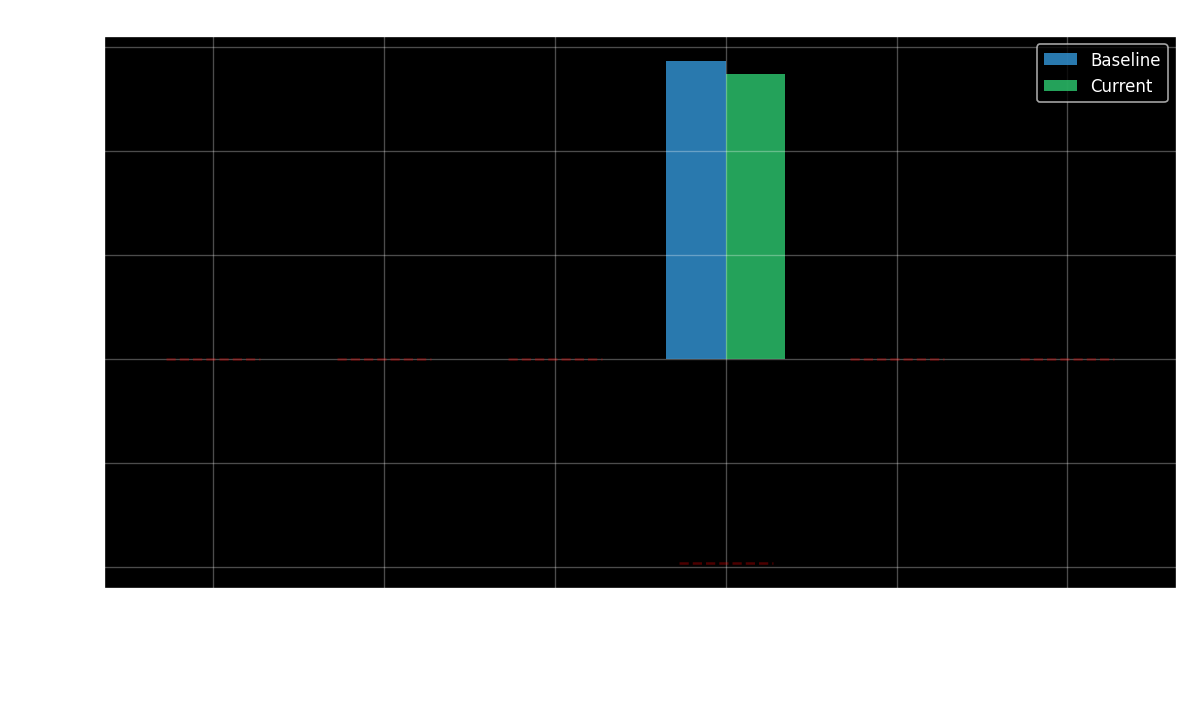

In [16]:
# ── Metric comparison: current vs baseline ──
if BASELINE_PATH.exists():
    with open(BASELINE_PATH) as f:
        baseline = json.load(f)

    metrics = sorted(set(baseline.keys()) & set(drift_metrics.keys()))
    baseline_vals = [baseline[m]["mean"] for m in metrics]
    current_vals = [drift_metrics[m] for m in metrics]
    baseline_stds = [baseline[m]["std"] for m in metrics]

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(metrics))
    width = 0.35
    bars1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline", color="#3498db", alpha=0.8)
    bars2 = ax.bar(x + width/2, current_vals, width, label="Current", color="#2ecc71", alpha=0.8)

    # Error bands on baseline
    for i, (bv, bs) in enumerate(zip(baseline_vals, baseline_stds)):
        ax.plot([i - width/2 - 0.1, i - width/2 + width + 0.1], [bv - 2*bs]*2, "r--", alpha=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=30, ha="right")
    ax.set_ylabel("Score")
    ax.set_title("Current Run vs Baseline")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No baseline yet — run the notebook once to establish it.")

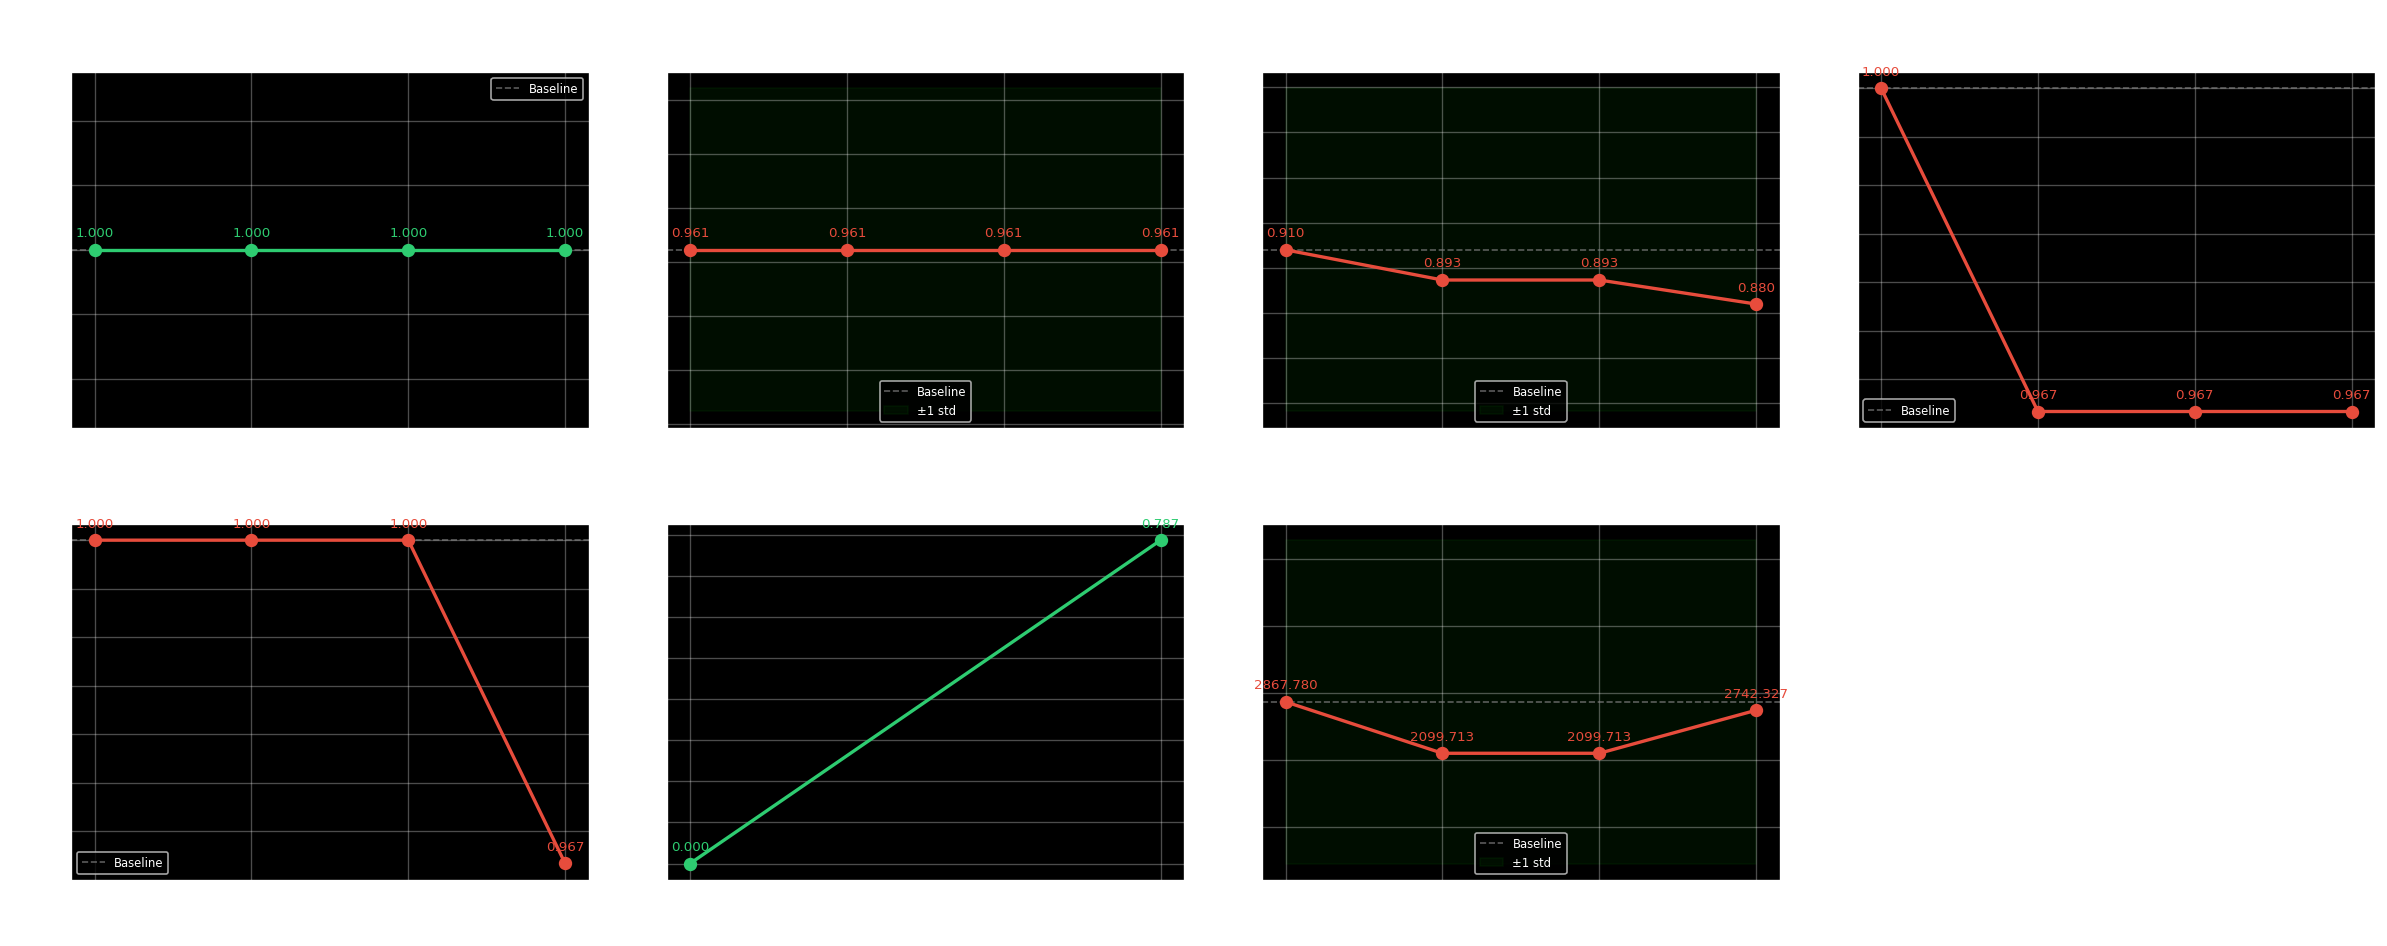

In [17]:
# ── Drift timeline + report table ──
if HISTORY_PATH.exists():
    history = []
    with open(HISTORY_PATH) as f:
        for line in f:
            line = line.strip()
            if line:
                history.append(json.loads(line))

    if len(history) > 1:
        hist_df = pd.DataFrame(history)
        hist_df["run"] = range(1, len(hist_df) + 1)

        timeline_metrics = [m for m in ["hit_rate", "mrr", "correctness_score",
                                         "hallucination_score", "relevance_score",
                                         "context_precision", "agent_accuracy", "latency_ms"]
                           if m in hist_df.columns]
        # Normalize latency for plotting
        n_metrics = len(timeline_metrics)
        ncols = min(n_metrics, 4)
        nrows = (n_metrics + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes_flat = np.array(axes).flatten() if n_metrics > 1 else [axes]

        # Load baseline once for banding
        baseline_stats = {}
        if BASELINE_PATH.exists():
            with open(BASELINE_PATH) as _bf:
                _bd = json.load(_bf)
            baseline_stats = _bd.get("metrics", _bd)

        for ax, metric in zip(axes_flat, timeline_metrics):
            vals = hist_df[metric].values
            runs = hist_df["run"].values

            # Trend line colour: green if last value ≥ baseline mean, red if below
            bm = baseline_stats.get(metric, {}).get("mean", None)
            color = "#2ecc71" if (bm is None or vals[-1] >= bm) else "#e74c3c"

            ax.plot(runs, vals, "o-", color=color, linewidth=2, markersize=7, zorder=3)
            # Annotate each point with its value
            for x, y in zip(runs, vals):
                ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                            xytext=(0, 8), ha="center", fontsize=8, color=color)

            if bm is not None:
                bs = baseline_stats[metric].get("std", 0)
                ax.axhline(bm, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Baseline")
                if bs > 0:
                    ax.fill_between(runs, bm - bs, bm + bs, alpha=0.1, color="green", label="±1 std")
                ax.legend(fontsize=7)

            ax.set_title(metric.replace("_", " ").title(), fontsize=11, fontweight="bold")
            ax.set_xlabel("Run #")
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

        for ax in axes_flat[n_metrics:]:
            ax.set_visible(False)
        fig.suptitle("Metric Trends Over Time  (green = at/above baseline, red = below)", fontsize=13)
        plt.tight_layout()
        plt.show()
    else:
        print("Only 1 run recorded — need 2+ runs for timeline chart.")

# Drift report table
if drift_report is not None:
    report_rows = []
    for m in drift_report.metrics:
        status = "\u26a0 DRIFT" if m.is_drifted else "\u2713 OK"
        report_rows.append({
            "Metric": m.metric, "Baseline Mean": round(m.baseline_mean, 3),
            "Baseline Std": round(m.baseline_std, 3), "Current Mean": round(m.current_mean, 3),
            "Delta": round(m.delta, 3), "Z-Score": round(m.z_score, 2), "Status": status,
        })
    pd.DataFrame(report_rows)
else:
    print("No drift report (first run).")

---
## Section 5 — Agent Evaluation

The RAG pipeline answers questions by retrieving and generating. But some questions need more:
calculations, date lookups, or multi-step reasoning. The **RAGAgent** wraps the pipeline as one
of several tools in a ReAct loop:

| Tool | Purpose |
|------|---------|
| `rag_query` | Search the knowledge base (factual lookup) |
| `calculator` | Evaluate math expressions |
| `date` | Get current date/time |

We test with 10 questions — a mix of RAG-only, calculator-only, and combined. For each, we
evaluate: Did the agent pick the right tool? How many steps did it take? Was the final answer
correct?

In [18]:
# ── Run agent on 10 test questions ──
agent = RAGAgent(pipeline=pipeline)

agent_tests = [
    {"question": "What is retrieval-augmented generation?",
     "expected": "RAG enables LLMs to retrieve information from external data sources",
     "optimal_tool": "rag_query"},
    {"question": "What is 15% of 340?",
     "expected": "51", "optimal_tool": "calculator"},
    {"question": "Explain the theory of relativity.",
     "expected": "The theory of relativity comprises two physics theories by Albert Einstein",
     "optimal_tool": "rag_query"},
    {"question": "What is 1024 divided by 16?",
     "expected": "64", "optimal_tool": "calculator"},
    {"question": "What is today's date?",
     "expected": datetime.now().strftime("%Y-%m-%d"), "optimal_tool": "date"},
    {"question": "What is a black hole?",
     "expected": "A black hole is an astronomical body so compact that its gravity prevents anything from escaping",
     "optimal_tool": "rag_query"},
    {"question": "What is the square root of 144?",
     "expected": "12", "optimal_tool": "calculator"},
    {"question": "What is CRISPR and what are its applications?",
     "expected": "CRISPR is a family of DNA sequences found in prokaryotic organisms",
     "optimal_tool": "rag_query"},
    {"question": "What is 2 to the power of 10?",
     "expected": "1024", "optimal_tool": "calculator"},
    {"question": "How does photosynthesis work?",
     "expected": "Photosynthesis is a system of biological processes converting light energy into chemical energy",
     "optimal_tool": "rag_query"},
]

agent_results = []
for i, test in enumerate(agent_tests):
    print(f"  [{i+1:2d}/10] {test['question'][:50]}...", end=" ", flush=True)
    t0 = time.time()
    result = agent.run(test["question"])
    elapsed = time.time() - t0
    agent_results.append({
        "question": test["question"],
        "expected": test["expected"],
        "optimal_tool": test["optimal_tool"],
        "answer": result.final_answer,
        "trajectory": result.trajectory,
        "trace_id": result.trace_id,
        "latency_ms": round(result.latency_ms, 1),
        "num_steps": len(result.trajectory),
    })
    tools_used = [s.tool for s in result.trajectory if s.tool]
    print(f"\u2713 {elapsed:.1f}s, steps={len(result.trajectory)}, tools={tools_used}")

print(f"\n\u2713 All 10 agent questions complete")

  [ 1/10] What is retrieval-augmented generation?... ✓ 1.8s, steps=1, tools=[]
  [ 2/10] What is 15% of 340?... ✓ 0.7s, steps=2, tools=['calculator']
  [ 3/10] Explain the theory of relativity.... ✓ 4.8s, steps=1, tools=[]
  [ 4/10] What is 1024 divided by 16?... ✓ 0.7s, steps=2, tools=['calculator']
  [ 5/10] What is today's date?... ✓ 0.7s, steps=2, tools=['date']
  [ 6/10] What is a black hole?... ✓ 3.1s, steps=2, tools=['rag_query']
  [ 7/10] What is the square root of 144?... ✓ 1.5s, steps=5, tools=[]
  [ 8/10] What is CRISPR and what are its applications?... ✓ 9.1s, steps=3, tools=['rag_query', 'rag_query']
  [ 9/10] What is 2 to the power of 10?... ✓ 1.6s, steps=5, tools=['calculator', 'calculator', 'calculator', 'calculator', 'calculator']
  [10/10] How does photosynthesis work?... ✓ 3.2s, steps=1, tools=[]

✓ All 10 agent questions complete


In [19]:
# ── Trajectory table ──
traj_rows = []
for i, ar in enumerate(agent_results):
    for step in ar["trajectory"]:
        traj_rows.append({
            "Run": i + 1,
            "Question": ar["question"][:35],
            "Step": step.step,
            "Tool": step.tool or ("FINAL" if step.is_final else "think"),
            "Input": (step.tool_input or "")[:40],
            "Output": (step.tool_output or step.thought[:60] if step.is_final else (step.tool_output or ""))[:60],
        })

traj_df = pd.DataFrame(traj_rows)
print(f"Agent Trajectories: {len(traj_df)} steps across {len(agent_results)} runs\n")
traj_df

Agent Trajectories: 24 steps across 10 runs



,Run,Question,Step,Tool,Input,Output
0,1,What is retrieval-augmented generat,0,FINAL,,FINAL: Retrieval-augmented generation (RAG) is...
1,2,What is 15% of 340?,0,calculator,340 * 0.15,51.0
2,2,What is 15% of 340?,1,FINAL,,FINAL: 51
3,3,Explain the theory of relativity.,0,FINAL,,"FINAL: The theory of relativity, developed by ..."
4,4,What is 1024 divided by 16?,0,calculator,1024 / 16,64.0
5,4,What is 1024 divided by 16?,1,FINAL,,FINAL: 64
6,5,What is today's date?,0,date,today,2026-04-11
7,5,What is today's date?,1,FINAL,,"FINAL: Today's date is April 11, 2026."
8,6,What is a black hole?,0,rag_query,What is a black hole?,A black hole is a region of spacetime with suc...
9,6,What is a black hole?,1,FINAL,,FINAL: A black hole is a region of spacetime w...


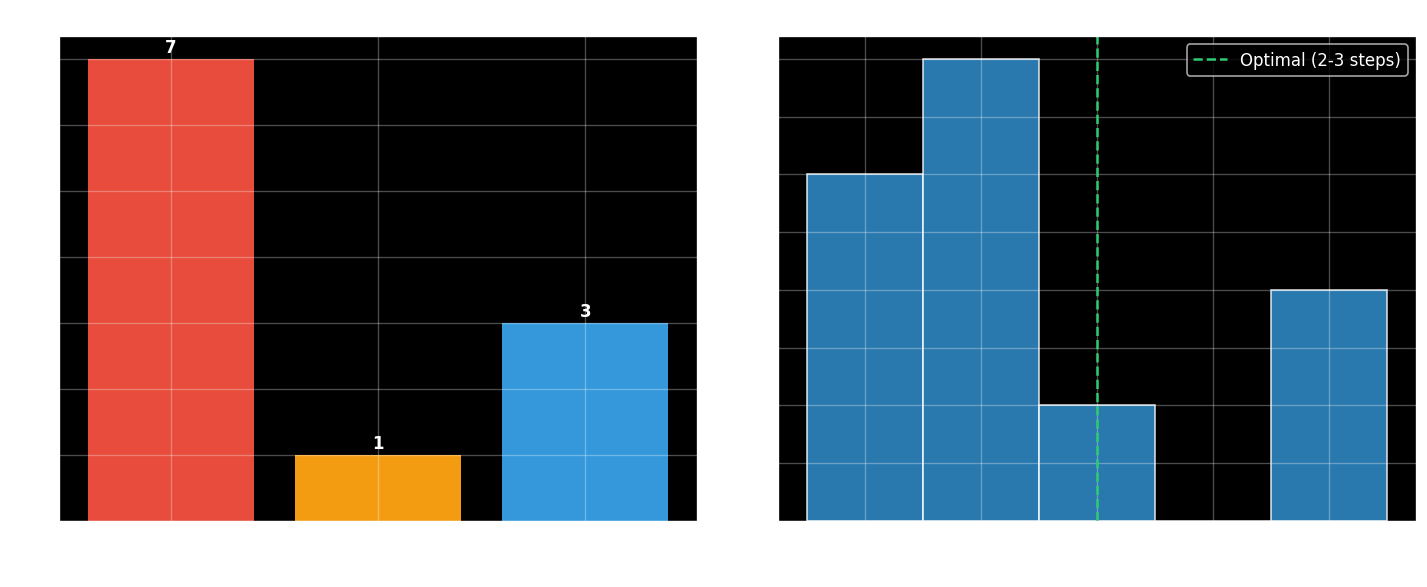

⚠ 2 runs took 5+ steps:
  - "What is the square root of 144?" (5 steps)
  - "What is 2 to the power of 10?" (5 steps)


In [20]:
# ── Tool usage bar chart + Step count histogram ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Tool usage
all_tools = []
for ar in agent_results:
    for step in ar["trajectory"]:
        if step.tool:
            all_tools.append(step.tool)
tool_counts = Counter(all_tools)
tool_colors = {"rag_query": "#3498db", "calculator": "#e74c3c", "date": "#f39c12"}
bars = ax1.bar(tool_counts.keys(), tool_counts.values(),
               color=[tool_colors.get(t, "#999") for t in tool_counts.keys()])
ax1.set_ylabel("Times Called")
ax1.set_title("Tool Usage Across All Agent Runs")
for bar, val in zip(bars, tool_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha="center", fontweight="bold")

# Step count
step_counts = [ar["num_steps"] for ar in agent_results]
ax2.hist(step_counts, bins=range(1, max(step_counts) + 2), color="#3498db",
         edgecolor="white", alpha=0.8, align="left")
ax2.axvline(3, color="#2ecc71", linestyle="--", label="Optimal (2-3 steps)")
ax2.set_xlabel("Steps per Question")
ax2.set_ylabel("Count")
ax2.set_title("Agent Step Count Distribution")
ax2.legend()

plt.tight_layout()
plt.show()

# Flag inefficient runs
slow = [ar for ar in agent_results if ar["num_steps"] >= 5]
if slow:
    print(f"\u26a0 {len(slow)} runs took 5+ steps:")
    for ar in slow:
        print(f"  - \"{ar['question'][:50]}\" ({ar['num_steps']} steps)")
else:
    print("\u2713 All agent runs completed in <5 steps.")

In [21]:
# ── Agent vs Direct RAG comparison ──
rag_questions = [ar for ar in agent_results if ar["optimal_tool"] == "rag_query"]

comparison_rows = []
for ar in rag_questions:
    # Run same question through direct pipeline
    direct = pipeline.query(ar["question"])
    comparison_rows.append({
        "Question": ar["question"][:50],
        "Agent Answer": ar["answer"][:60],
        "Direct RAG Answer": direct.answer[:60],
        "Expected": ar["expected"][:60],
        "Agent Latency (ms)": ar["latency_ms"],
        "Direct Latency (ms)": round(direct.latency_ms, 1),
    })

comp_df = pd.DataFrame(comparison_rows)
print("Agent vs Direct RAG (for knowledge-base questions only)")
print("=" * 80)

# Post agent eval scores
for ar in agent_results:
    traj_dicts = [{"tool": s.tool, "tool_input": s.tool_input, "is_final": s.is_final}
                  for s in ar["trajectory"]]
    try:
        post_code_eval_scores(
            [ar["trace_id"]], "tool_accuracy",
            [1.0 if ar["optimal_tool"] in [s.tool for s in ar["trajectory"] if s.tool] else 0.0],
        )
        post_code_eval_scores(
            [ar["trace_id"]], "step_efficiency",
            [1.0 if ar["num_steps"] <= 3 else (0.5 if ar["num_steps"] <= 5 else 0.2)],
        )
    except Exception:
        pass

comp_df

Agent vs Direct RAG (for knowledge-base questions only)


,Question,Agent Answer,Direct RAG Answer,Expected,Agent Latency (ms),Direct Latency (ms)
0,What is retrieval-augmented generation?,Retrieval-augmented generation (RAG) is a tech...,Retrieval-augmented generation (RAG) is a tech...,RAG enables LLMs to retrieve information from ...,1752.9,1941.9
1,Explain the theory of relativity.,"The theory of relativity, developed by Albert ...",ing that the laws of physics are the same for ...,The theory of relativity comprises two physics...,4798.9,2542.5
2,What is a black hole?,A black hole is a region of spacetime with suc...,A black hole is a region of spacetime with a g...,A black hole is an astronomical body so compac...,3099.2,1233.9
3,What is CRISPR and what are its applications?,CRISPR (Clustered Regularly Interspaced Short ...,nd archaea that serve as a defense mechanism a...,CRISPR is a family of DNA sequences found in p...,9092.5,2082.0
4,How does photosynthesis work?,"Photosynthesis is a process used by plants, al...",Photosynthesis converts light energy into chem...,Photosynthesis is a system of biological proce...,3238.7,1611.8


---
## Section 6 — End-to-End Summary

Pulling everything together: a radar chart showing overall pipeline health, a summary table with
RAG status per component, and direct links to explore the results in Phoenix.

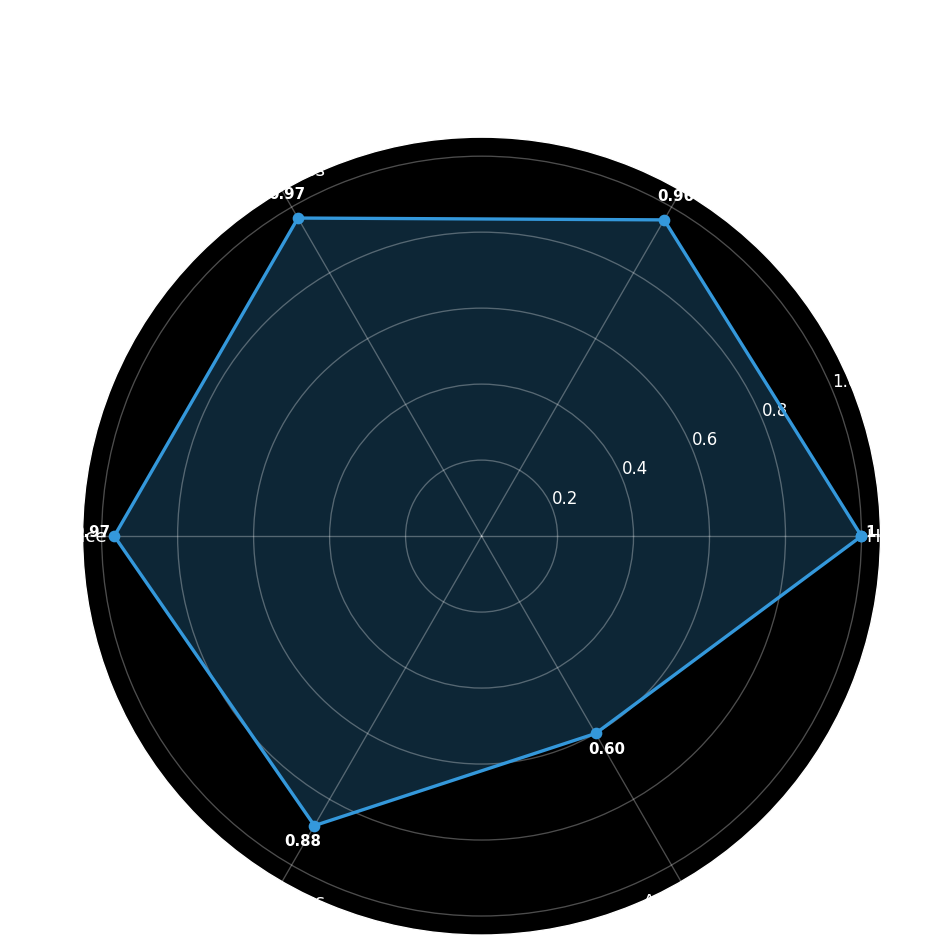

In [22]:
# ── Radar chart: overall pipeline health ──
try:
    df
except NameError:
    df = pd.read_csv("eval_results.csv")

hit_rate_avg = df["hit_rate"].mean() if "hit_rate" in df.columns else 0
mrr_avg = df["mrr"].mean() if "mrr" in df.columns else 0
faith_avg = df["hallucination_numeric"].mean() if "hallucination_numeric" in df.columns else 0
rel_avg = df["relevance_numeric"].mean() if "relevance_numeric" in df.columns else 0
corr_avg = df["correctness_numeric"].mean() if "correctness_numeric" in df.columns else 0

# Agent accuracy
agent_tools_correct = sum(
    1 for ar in agent_results
    if ar["optimal_tool"] in [s.tool for s in ar["trajectory"] if s.tool]
)
agent_acc = agent_tools_correct / len(agent_results) if agent_results else 0

categories = ["Hit Rate", "MRR", "Faithfulness", "Relevance", "Correctness", "Agent Acc."]
values = [hit_rate_avg, mrr_avg, faith_avg, rel_avg, corr_avg, agent_acc]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values_plot = values + values[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, values_plot, alpha=0.25, color="#3498db")
ax.plot(angles, values_plot, "o-", color="#3498db", linewidth=2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("RAG Pipeline Health", size=16, y=1.12)

# Add value labels
for angle, val, cat in zip(angles[:-1], values, categories):
    ax.text(angle, val + 0.06, f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

In [23]:
# ── Summary table ──
def status(score, warn=0.6, ok=0.7):
    if score >= ok:
        return "\u2713 OK"
    elif score >= warn:
        return "\u26a0 WARN"
    return "\u2717 FAIL"

drift_status = "\u2713 none detected"
if drift_report is not None and drift_report.any_drift:
    n_drifted = sum(1 for m in drift_report.metrics if m.is_drifted)
    drift_status = f"\u26a0 {n_drifted} metric(s) drifted"

summary_rows = [
    {"Component": "Retrieval (hit@5)", "Score": f"{hit_rate_avg:.2f}", "Status": status(hit_rate_avg)},
    {"Component": "Retrieval (MRR)", "Score": f"{mrr_avg:.2f}", "Status": status(mrr_avg, 0.5, 0.6)},
    {"Component": "Hallucination", "Score": f"{faith_avg:.0%} faithful", "Status": status(faith_avg, 0.7, 0.85)},
    {"Component": "Relevance", "Score": f"{rel_avg:.2f} avg", "Status": status(rel_avg)},
    {"Component": "Correctness", "Score": f"{corr_avg:.2f} avg", "Status": status(corr_avg, 0.5, 0.6)},
    {"Component": "Drift", "Score": drift_status, "Status": drift_status.split()[0]},
    {"Component": "Agent Accuracy", "Score": f"{agent_acc:.2f}", "Status": status(agent_acc)},
]

summary_df = pd.DataFrame(summary_rows)
print("RAG Pipeline Summary")
print("=" * 60)
print(summary_df.to_string(index=False))

print(f"\n\n\u2500" * 60)
print(f"Phoenix Dashboard:       {PHOENIX_URL}")
print(f"Project:                 {PROJECT_NAME}")
print(f"Traces from this run:    {PHOENIX_URL} \u2192 project '{PROJECT_NAME}'")
print(f"Evaluation annotations:  visible in each trace's Evaluations panel")
print(f"\nArtifacts saved:")
print(f"  pipeline_results.csv   ({len(df)} queries)")
print(f"  eval_results.csv       ({len(df)} queries + eval scores)")
print(f"  baseline.json          (drift baseline)")
print(f"  run_history.jsonl      (run log)")

RAG Pipeline Summary
        Component           Score Status
Retrieval (hit@5)            1.00   ✓ OK
  Retrieval (MRR)            0.96   ✓ OK
    Hallucination    97% faithful   ✓ OK
        Relevance        0.97 avg   ✓ OK
      Correctness        0.88 avg   ✓ OK
            Drift ✓ none detected      ✓
   Agent Accuracy            0.60 ⚠ WARN


─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─

─
Phoenix Dashboard:       http://localhost:6006
Project:                 rag-pipeline
Traces from this run:    http://localhost:6006 → project 'rag-pipeline'
Evaluation annotations:  visible in each trace's Evaluations panel

Artifacts saved:
  pipeline_results.csv   (30 queries)
  eval_results.csv       (30 queries + eval scores)
  baseline.json          (drift baseline)
  run_history.jsonl      (run log)
